# Online vs Offline (Active vs Background) Experiment

This notebook simulates and visualizes the RTT (Round Trip Time) differences between various device states (Active, Idle, Dozing) to understand distinguishability.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Add simulator to path
sys.path.append(os.path.abspath("../simulator"))

from receipt_generator import ReceiptGenerator
from device_state_model import DeviceState, DeviceStateModel, DEFAULT_DEVICE_STATES
from network_delay_model import NetworkDelayModel, WIFI, CELLULAR

## 1. Setup Simulation

We initialize the models. We will use `WIFI` as the network baseline to clearly observe device-side delay differences.

In [2]:
# Setup Models
network_model = NetworkDelayModel(profile=WIFI, seed=42)
device_model = DeviceStateModel(state_profiles=DEFAULT_DEVICE_STATES, seed=42)
generator = ReceiptGenerator(device_model=device_model, network_model=network_model)

SAMPLES = 1000

## 2. Generate Data

We simulate receipt RTTs for three distinct states:
*   **Active**: User is actively using the app.
*   **Idle**: App is in background but device is awake.
*   **Dozing**: Device is in deep sleep/doze mode.

In [3]:
results = []

# Compare Active vs Idle vs Dozing
# Note: 'Offline' generates no receipts, so it is not plotted here.
for state in [DeviceState.ACTIVE, DeviceState.IDLE, DeviceState.DOZING]:
    delays = []
    for _ in range(SAMPLES):
        rtt = generator.generate_receipt(state)
        if rtt is not None:
            delays.append(rtt)
    
    # Store in dataframe format
    for d in delays:
        results.append({"State": state.value, "RTT": d})

df = pd.DataFrame(results)
print(df.groupby("State")["RTT"].describe())

         count        mean        std         min         25%         50%  \
State                                                                       
active  1000.0   52.282888   9.450653   45.025149   48.226188   50.570190   
dozing  1000.0  267.909344  43.626748  191.273479  230.847358  267.969845   
idle    1000.0   99.964194  15.707219   80.128829   91.686955  100.191226   

               75%         max  
State                           
active   54.064987  178.023660  
dozing  302.974064  423.318444  
idle    106.114633  355.821856  


## 3. RTT Distribution & Overlap Visualization

We visualize the distributions to see how distinct they are.

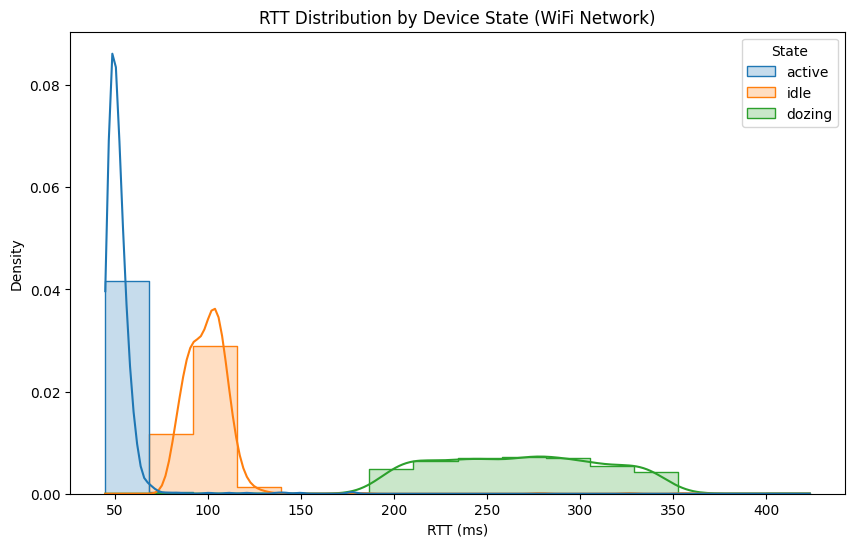

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="RTT", hue="State", kde=True, element="step", stat="density", common_norm=False)
plt.title("RTT Distribution by Device State (WiFi Network)")
plt.xlabel("RTT (ms)")
plt.show()

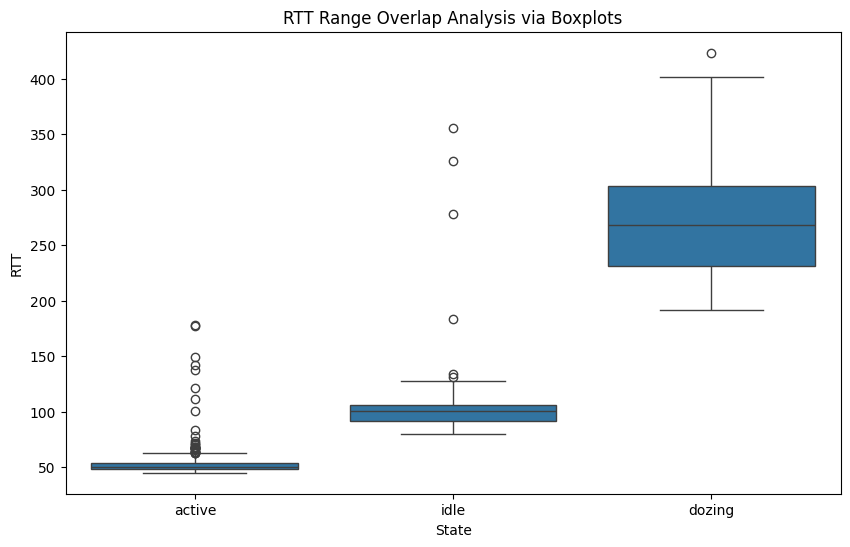

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="State", y="RTT")
plt.title("RTT Range Overlap Analysis via Boxplots")
plt.show()

## 4. False Positive Discussion

A **False Positive** in this context would be classifying a user as **Active** (Online) when they are actually **Idle** or **Dozing** (effectively "Offline" from a user-presence perspective), based solely on a low RTT.

Since network variance can be low (especially on WiFi), the distinction is driven by device processing delays.

In [6]:
# Example: Simple Threshold Classifier
# Let's say we assume any RTT < Threshold implies "Active"

threshold = 60 # ms (Example threshold)

active_classified = df[df["RTT"] < threshold]
false_positives = active_classified[active_classified["State"] != "active"]

fp_count = len(false_positives)
total_classified_active = len(active_classified)
fp_rate = fp_count / total_classified_active if total_classified_active > 0 else 0

print(f"Threshold: {threshold} ms")
print(f"Total classified as Active: {total_classified_active}")
print(f"False Positives (Actually Idle/Dozing): {fp_count}")
print(f"False Positive Rate (Precision): {fp_rate:.2%}")

Threshold: 60 ms
Total classified as Active: 935
False Positives (Actually Idle/Dozing): 0
False Positive Rate (Precision): 0.00%


### Interpretation

- If the distributions overlap significantly, single-packet classification is unreliable.
- **Active** RTTs are generally tight and low.
- **Idle/Dozing** RTTs have higher base delays and significantly higher jitter.
- However, random jitter means an Idle device *can* occasionally respond quickly, mimicking an Active user (False Positive).